Running simulation...
Measurement Counts: {'110': 29, '101': 34, '010': 104, '000': 263, '111': 198, '011': 141, '100': 255}


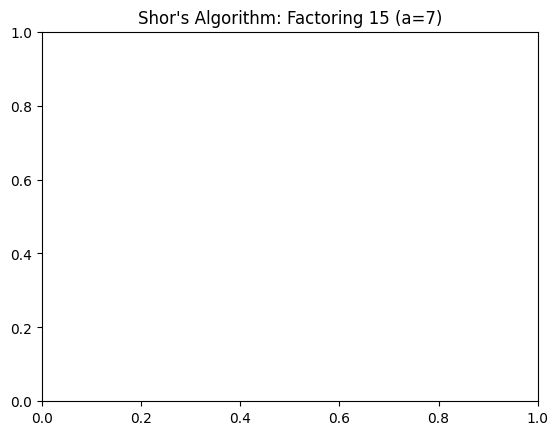

In [ ]:
from qiskit import qasm3
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt

# 1. The complete OpenQASM 3.0 string
qasm_string = """
OPENQASM 3.0;
include "stdgates.inc";

// Define 7 qubits and 3 classical bits for measurement
qubit[7] q;
bit[3] c;

// --- INITIALIZATION ---
// Put the counting register in superposition
h q[0];
h q[1];
h q[2];
// Set target register to |0001>
x q[3];

// --- ORACLE: Calculate 7^x mod 15 ---
// Multiply by 7 (Controlled by q[0])
cswap q[0], q[3], q[6];
cswap q[0], q[3], q[5];
cswap q[0], q[3], q[4];
cx q[0], q[3];
cx q[0], q[4];
cx q[0], q[5];
cx q[0], q[6];

// Multiply by 4 (Controlled by q[1])
cswap q[1], q[3], q[5];
cswap q[1], q[4], q[6];

// Multiply by 16 (Controlled by q[2]) - Does nothing (16 mod 15 = 1)

// --- INVERSE QUANTUM FOURIER TRANSFORM (CORRECTED) ---
// 1. Undo wire order
swap q[0], q[2];

// 2. Unwind q[0] first
h q[0];

// 3. Unwind q[1]
cp(-pi/2) q[0], q[1];
h q[1];

// 4. Unwind q[2]
cp(-pi/4) q[0], q[2];
cp(-pi/2) q[1], q[2];
h q[2];

// --- MEASUREMENT ---
c[0] = measure q[0];
c[1] = measure q[1];
c[2] = measure q[2];
"""

# 2. Parse the QASM 3 string into a Qiskit QuantumCircuit
circuit = qasm3.loads(qasm_string)

# 3. Set up the local Aer Simulator
simulator = AerSimulator()

# 4. Execute the circuit (1024 shots)
print("Running simulation...")
job = simulator.run(circuit, shots=1024)
result = job.result()

# 5. Extract and display the results
counts = result.get_counts()
print(f"Measurement Counts: {counts}")

# Display histogram directly from plot_histogram
fig = plot_histogram(counts, title="Shor's Algorithm: Factoring 15 (a=7)")
fig.show()



NameError: name 'code' is not defined

SyntaxError: invalid syntax (3060095519.py, line 1)